In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib.image as img
import pandas as pd
import os
from pathlib import Path
import read_sim_not_clin_bg as rsnb

### Для просмотра файлов в папке

In [2]:
# folder_path = '/media/alexandra/DATA/IACT02_2020-2021' # второй телескоп
folder_path = '/media/alexandra/DATA/IACT01_2020-2021' # первый телескоп

# Cписок файлов в папке
file_names = os.listdir(folder_path)

# Выводим названия файлов
for file_name in file_names:
    # print(file_name)
    break

### Считываем файлы в таблицу

In [3]:
# folder_path = '/media/alexandra/DATA/IACT02_2020-2021'
folder_path = '/media/alexandra/DATA/IACT01_2020-2021'
df_19 = pd.read_csv('/media/alexandra/DATA/IACT01_231119/231119.01_out_hillas_14_7.0fix.csv') # 19-год (один день)

# Cписок всех CSV-файлов в папке
file_paths = [os.path.join(folder_path, file) for file in os.listdir(folder_path) if file.endswith('.csv')]

# Читаем каждый файл и объединяем их в один DataFrame
dataframes = [pd.read_csv(file) for file in file_paths]
hillas = pd.concat(dataframes, ignore_index=True)
combined_hillas = pd.concat([df_19, hillas], ignore_index=True)

hillas

,por,event_numb,time,unix_time_ns,delta_time,error_deg,tel_az,tel_el,source_az,source_el,...,source_ra,source_dec,source_x,source_y,tracking,good,star,edge,weather_mark,alpha_c
0,1,14,13:37:23:280:261:540,1612791443280261540,0.22,0.03,181.85089,60.151,184.37523,60.168,...,83.63,22.01,1.28,-0.02,1,1,0,0,9.09,0.93
1,1,70,13:37:23:362:354:610,1612791443362354610,0.14,0.03,181.85089,60.151,184.37523,60.168,...,83.63,22.01,1.28,-0.02,1,1,0,0,9.09,0.93
2,1,116,13:37:23:411:776:330,1612791443411776330,0.09,0.03,181.85089,60.151,184.37523,60.168,...,83.63,22.01,1.28,-0.02,1,1,0,0,9.09,0.93
3,1,149,13:37:23:444:607:650,1612791443444607650,0.06,0.03,181.85089,60.151,184.37523,60.168,...,83.63,22.01,1.28,-0.02,1,1,0,0,9.09,0.93
4,1,169,13:37:23:465:362:590,1612791443465362590,0.03,0.03,181.85089,60.151,184.37523,60.168,...,83.63,22.01,1.28,-0.02,1,1,0,0,9.09,0.93
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3296949,67,887272,16:24:00:251:741:530,1612628640251741530,0.25,0.03,244.91386,45.279,243.62814,46.048,...,83.63,22.01,-0.90,-0.80,0,0,0,0,-1.00,0.49
3296950,67,887273,16:24:00:252:921:020,1612628640252921020,0.25,0.03,244.91386,45.279,243.62814,46.048,...,83.63,22.01,-0.90,-0.80,0,0,0,0,-1.00,0.49
3296951,67,887282,16:24:00:406:925:590,1612628640406925590,0.09,0.03,244.91386,45.279,243.62814,46.048,...,83.63,22.01,-0.90,-0.80,0,0,0,0,-1.00,0.49
3296952,67,887283,16:24:00:421:163:880,1612628640421163880,0.08,0.03,244.91386,45.279,243.62814,46.048,...,83.63,22.01,-0.90,-0.80,0,0,0,0,-1.00,0.49


### Применяем каты

In [4]:
def filter_hillas_data(df):
    # Common filters for both source and anti-source
    common_filters = (
        (df['CR_portion']/np.cos(np.pi/2-np.pi*df['tel_el']/180) > 5) &
        (df['size'] > 120) &
        (df['width'] > 0.024) &
        (df['width'] < 0.068 * np.log10(df['size']) - 0.047) &
        (df['length'] < 0.145 * np.log10(df['size']))
    )
    
    # Source selection (dist1)
    source_df = df[
        common_filters &
        (df['dist1'].between(0.36, 1.44))
    ].copy()
    source_df['source_type'] = 'source'  # Add identifier column
    
    # Anti-source selection (dist2)
    anti_source_df = df[
        common_filters &
        (df['dist2'].between(0.36, 1.44))
    ].copy()
    anti_source_df['source_type'] = 'anti-source'  # Add identifier column
    
    return source_df, anti_source_df

source_events, antisource_events = filter_hillas_data(df_19)
source_events

,por,event_numb,time,unix_time_ns,delta_time,error_deg,tel_az,tel_el,source_az,source_el,...,source_dec,source_x,source_y,tracking,good,star,edge,weather_mark,alpha_c,source_type
709,1,13650,16:00:10:513:944:670,1574524810513944670,0.01,0.03,118.95592,47.336,120.40375,48.035,...,22.01,0.99,-0.71,1,1,0,0.0,9.31,0.51,source
1574,2,26697,16:01:42:662:894:080,1574524902662894080,0.16,0.03,119.38536,47.540,120.84088,48.239,...,22.01,0.99,-0.71,1,1,1,0.0,9.36,0.51,source
2351,2,32070,16:02:53:749:452:180,1574524973749452180,0.25,0.03,119.71657,47.702,121.18010,48.397,...,22.01,0.99,-0.71,1,1,0,0.0,9.32,0.51,source
2360,2,32125,16:02:54:502:714:070,1574524974502714070,0.00,0.03,119.72204,47.703,121.18489,48.399,...,22.01,0.99,-0.71,1,1,0,0.0,9.32,0.51,source
2668,3,34895,16:03:34:464:161:100,1574525014464161100,0.04,0.03,119.91109,47.795,121.37673,48.487,...,22.01,0.99,-0.70,1,1,1,0.0,9.33,0.51,source
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204384,137,1980882,21:00:02:206:774:700,1574542802206774700,0.21,0.03,239.02795,48.301,237.52513,48.984,...,22.01,-1.00,-0.71,1,1,0,0.0,9.07,0.36,source
205056,137,1985258,21:01:12:396:970:200,1574542872396970200,0.40,0.03,239.36333,48.143,237.86575,48.831,...,22.01,-1.00,-0.72,1,1,0,0.0,9.05,0.35,source
205490,138,1988450,21:02:09:852:156:110,1574542929852156110,0.15,0.03,239.63636,48.013,238.14674,48.704,...,22.01,-0.99,-0.72,1,1,0,0.0,9.04,0.35,source
205740,138,1990099,21:02:35:978:715:980,1574542955978715980,0.02,0.03,239.75992,47.950,238.27234,48.647,...,22.01,-0.99,-0.72,1,1,1,0.0,9.03,0.35,source


### Гистограмма по тета

/tmp/ipykernel_3886/1845326320.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  source_events['disp'] = source_events['ksi'] * (1.0 - source_events['width'] / source_events['length'])
/tmp/ipykernel_3886/1845326320.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  source_events['theta2'] = (source_events['disp']**2 + source_events['dist1']**2 -


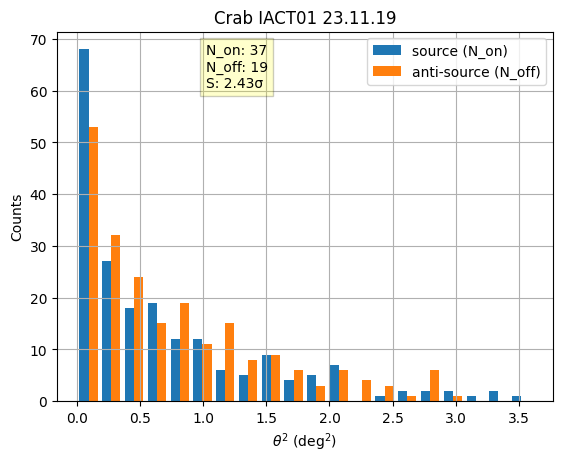

N_on = 37, N_off = 19, Significance = 2.43σ
        por  event_numb                  time         unix_time_ns  \
143       1        2805  15:59:15:694:170:230  1574524755694170230   
284       1        5427  15:59:28:817:664:770  1574524768817664770   
2416      2       32527  16:02:59:790:376:570  1574524979790376570   
3169      3       38332  16:04:19:892:378:820  1574525059892378820   
4658      4       49475  16:06:51:917:965:540  1574525211917965540   
...     ...         ...                   ...                  ...   
204464  137     1981434  21:00:11:056:770:090  1574542811056770090   
205056  137     1985258  21:01:12:396:970:200  1574542872396970200   
205821  138     1990529  21:02:43:038:505:770  1574542963038505770   
206528  138     1995005  21:03:56:986:529:370  1574543036986529370   
206592  138     1995382  21:04:03:121:594:380  1574543043121594380   

        delta_time  error_deg     tel_az  tel_el  source_az  source_el  ...  \
143           0.19       0.03  118.7

In [5]:
def calculate_ksi(rc, size):
    if rc < 7.5:
        return 1.3
    elif 7.5 < rc < 10:
        return 1.6
    elif rc > 10:
        if size < 700:
            return 2.0
        elif 700 < size < 1000:
            return 1.9
        elif 1000 < size < 1250:
            return 1.75
        elif 1250 < size < 1500:
            return 1.5
    return np.nan

# Process source events (N_on)
source_events['rc'] = source_events['dist1'] / 0.1206
source_events['ksi'] = source_events.apply(lambda row: calculate_ksi(row['rc'], row['size']), axis=1)
source_events = source_events[~source_events['ksi'].isna()]  # Remove NaN values
source_events['disp'] = source_events['ksi'] * (1.0 - source_events['width'] / source_events['length'])
source_events['theta2'] = (source_events['disp']**2 + source_events['dist1']**2 - 
                          2 * source_events['disp'] * source_events['dist1'] * np.cos(np.radians(source_events['alpha1'])))

# Process anti-source events (N_off)
antisource_events['rc'] = antisource_events['dist2'] / 0.1206
antisource_events['ksi'] = antisource_events.apply(lambda row: calculate_ksi(row['rc'], row['size']), axis=1)
antisource_events = antisource_events[~antisource_events['ksi'].isna()]  # Remove NaN values
antisource_events['disp'] = antisource_events['ksi'] * (1.0 - antisource_events['width'] / antisource_events['length'])
antisource_events['theta2'] = (antisource_events['disp']**2 + antisource_events['dist2']**2 - 
                              2 * antisource_events['disp'] * antisource_events['dist2'] * np.cos(np.radians(antisource_events['alpha2'])))

# Create histogram
plt.hist([source_events['theta2'], antisource_events['theta2']], 
         bins=20, label=['source (N_on)', 'anti-source (N_off)'])
plt.legend(loc='upper right')
plt.xlabel(r'$\theta^2$ (deg$^2$)')
plt.ylabel('Counts')
plt.title('Crab IACT01 23.11.19')

# Calculate statistics (using θ² < 0.05 cut)
theta_cut = 0.05
N_on = len(source_events[source_events['theta2'] < theta_cut])
N_off = len(antisource_events[antisource_events['theta2'] < theta_cut])

# Calculate significance
S = round(np.sqrt(2 * N_on * np.log(2 * (N_on / (N_on + N_off))) + 2 * N_off * np.log(2 * (N_off / (N_on + N_off)))), 2)

plt.annotate(f"N_on: {N_on}\nN_off: {N_off}\nS: {S}σ", 
             fontsize=10, bbox={'facecolor': 'yellow', 'alpha': 0.2},
             xy=(0.3, 0.85), xycoords='axes fraction')

plt.grid()
plt.show()

print(f'N_on = {N_on}, N_off = {N_off}, Significance = {S}σ')
print(antisource_events);

### Гистограмма по alpha

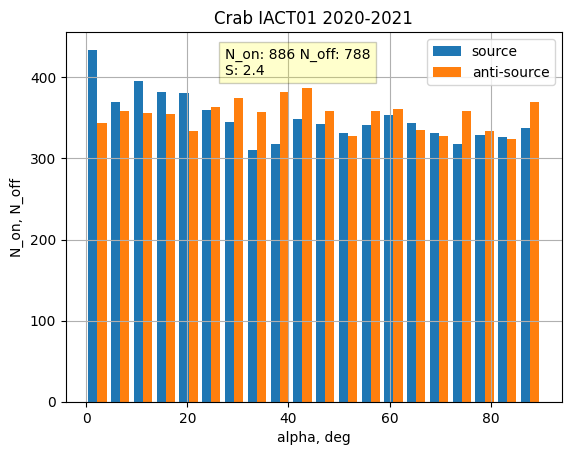

N_on = 886 N_off = 788 S_lima = 2.4


In [6]:
# та же самая функция, что выше только с доп катами, как у Паши В
# def filter_hillas_data(df):
#     common_filters = (
#         (df['CR_portion']/np.cos(np.pi/2-np.pi*df['tel_el']/180) > 5) &
#         (df['delta_time'] < 0.5) &
#         (df['error_deg'] < 0.1) &
#         (df['size'] > 120) &
#         (df['width'] > 0.024) &
#         (df['width'] < 0.068 * np.log10(df['size']) - 0.047) &
#         (df['length'] < 0.145 * np.log10(df['size']))
#     )
#     source_df = df[
#         common_filters &
#         (df['dist1'].between(0.36, 1.44))
#     ].copy()
#     source_df['source_type'] = 'source' 
    
#     anti_source_df = df[
#         common_filters &
#         (df['dist2'].between(0.36, 1.44))
#     ].copy()
#     anti_source_df['source_type'] = 'anti-source'
#     return source_df, anti_source_df

source_events, antisource_events = filter_hillas_data(hillas)

plt.hist([source_events['alpha1'],antisource_events['alpha2']], bins=20,
            label=['source', 'anti-source'])#,stacked=True)  
plt.legend(loc='upper right')
plt.xlabel('alpha, deg')
plt.ylabel('N_on, N_off')
plt.title('Crab IACT01 2020-2021') 
N_on = len(source_events.loc[source_events['alpha1']<10])
N_off = len(antisource_events.loc[antisource_events['alpha2']<10])
S = round(np.sqrt(2*N_on*np.log(2*(N_on/(N_on+N_off))) + 2*N_off*np.log(2*(N_off/(N_on+N_off)))),2) #сигма
plt.annotate(f"N_on: {N_on} N_off: {N_off}\nS: {S}", fontsize=10,
            bbox={'facecolor':'yellow','alpha':0.2},
              xy=(3, 21), xytext=(0.32, 0.885), textcoords='axes fraction')
plt.grid()
plt.show()
print('N_on =', N_on, 'N_off =', N_off, 'S_lima =', S)

N_on = 431.0 N_off = 342.0 3.2011075056319482 3.2


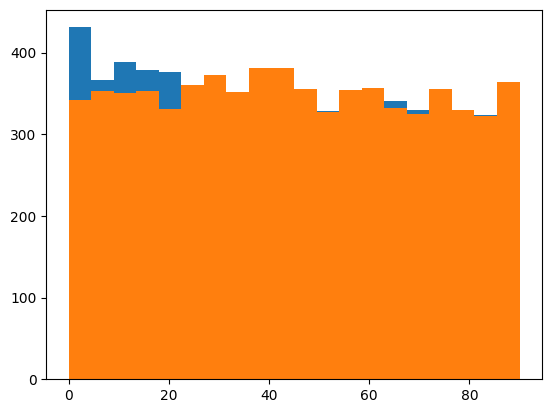

In [7]:
# Пашин В. вариант по альфа
# table_had = pd.read_csv('/media/alexandra/DATA/IACT01_231119/231119.01_out_hillas_14_7.0fix.csv') #23.11.19
table_had = hillas

on10 = plt.hist(table_had['alpha1'][(table_had['CR_portion']/np.cos(np.pi/2-np.pi*table_had['tel_el']/180) > 5) & 
                      (table_had['delta_time'] < 0.5) &
                      (table_had['error_deg'] < 0.1) &
                      (table_had['size'] > 120) & 
                      (table_had['dist1'] > 0.36) & 
                      (table_had['dist1'] < 1.44) & 
                      (table_had['width'] > 0.024) & 
                      (table_had['width'] < (0.068*np.log10(table_had['size'])-0.047)) &
                      (table_had['length'] <0.145*np.log10(table_had['size']))], range=[0,90], bins=20)[0]
off10 = plt.hist(table_had['alpha2'][(table_had['CR_portion']/np.cos(np.pi/2-np.pi*table_had['tel_el']/180) > 5) & 
                      (table_had['delta_time'] < 0.5) &
                      (table_had['error_deg'] < 0.1) &
                      (table_had['size'] > 120) & 
                      (table_had['dist2'] > 0.36) & 
                      (table_had['dist2'] < 1.44) & 
                      (table_had['width'] > 0.024) & 

                      (table_had['width'] < (0.068*np.log10(table_had['size'])-0.047)) &
                      (table_had['length'] <0.145*np.log10(table_had['size']))], range=[0,90], bins=20)[0]
N_on = on10[0]
N_off = off10[0]
S_lima = round(np.sqrt(2*N_on*np.log(2*(N_on/(N_on+N_off))) + 2*N_off*np.log(2*(N_off/(N_on+N_off)))),2) #сигма
print('N_on =', on10[0], 'N_off =', off10[0], (on10[0] - off10[0])/np.sqrt(on10[0] + off10[0]), S_lima)

### Пересчитываем параметры для 4 точек фона

In [41]:
df_19

,por,event_numb,time,unix_time_ns,delta_time,error_deg,tel_az,tel_el,source_az,source_el,...,bg2_dist,bg2_alpha,bg3_x,bg3_y,bg3_dist,bg3_alpha,bg4_x,bg4_y,bg4_dist,bg4_alpha
0,1,14,15:59:01:558:835:010,1574524741558835010,0.44,0.03,118.64135,47.181,120.08002,47.882,...,2.268964,3.801018,-0.71,-0.99,2.038822,64.849910,1.202082,0.197990,1.398709,14.584318
1,1,24,15:59:01:633:642:980,1574524741633642980,0.37,0.03,118.64135,47.181,120.08002,47.882,...,2.913490,36.725579,-0.71,-0.99,1.699971,19.953159,1.202082,0.197990,2.177635,49.780119
2,1,28,15:59:01:654:668:020,1574524741654668020,0.35,0.03,118.64135,47.181,120.08002,47.882,...,3.088953,62.994224,-0.71,-0.99,3.039472,109.839887,1.202082,0.197990,3.786868,73.366975
3,1,30,15:59:01:669:731:650,1574524741669731650,0.33,0.03,118.64135,47.181,120.08002,47.882,...,1.731582,51.339049,-0.71,-0.99,3.693345,18.135801,1.202082,0.197990,2.652040,55.321884
4,1,40,15:59:01:704:527:060,1574524741704527060,0.30,0.03,118.64135,47.181,120.08002,47.882,...,4.011269,50.620724,-0.71,-0.99,1.617263,60.832633,1.202082,0.197990,3.863963,64.051079
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206599,138,1995440,21:04:04:093:403:660,1574543044093403660,4.59,0.03,240.15575,47.771,238.67420,48.464,...,1.791623,119.358054,-0.72,0.99,4.072629,100.406921,-0.190919,-1.209153,1.869021,89.796231
206600,138,1995450,21:04:04:246:995:490,1574543044246995490,4.75,0.03,240.15575,47.771,238.67420,48.464,...,2.079952,39.591603,-0.72,0.99,3.635916,0.610597,-0.190919,-1.209153,1.475431,16.014483
206601,138,1995453,21:04:04:280:441:380,1574543044280441380,4.78,0.03,240.15575,47.771,238.67420,48.464,...,1.251446,97.139544,-0.72,0.99,1.744882,154.394724,-0.190919,-1.209153,0.563985,52.614913
206602,138,1995454,21:04:04:291:544:180,1574543044291544180,4.79,0.03,240.15575,47.771,238.67420,48.464,...,1.963784,140.050080,-0.72,0.99,2.359842,71.778881,-0.190919,-1.209153,1.031101,143.630210


In [57]:
# генерим точки и считаем дист, альфа
def add_background_points_columns(df):
    # Создаем копию DataFrame чтобы избежать предупреждений
    df = df.copy()
    
    # Координаты центра камеры
    center_x, center_y = 0, 0
    # Создаем новые столбцы для 4 фоновых точек
    for i in range(4):
        if i == 0:
            # Диаметрально противоположная точка
            bg_x = -df['source_x']
            bg_y = -df['source_y']
        elif i == 1:
            # Первая перпендикулярная точка (поворот на 90°)
            bg_x = -df['source_y']
            bg_y = df['source_x']
        elif i == 2:
            # Вторая перпендикулярная точка (поворот на -90°)
            bg_x = df['source_y']
            bg_y = -df['source_x']
        elif i == 3:
            # Точка с поворотом на 45°
            bg_x = (df['source_x'] - df['source_y'])/np.sqrt(2)
            bg_y = (df['source_x'] + df['source_y'])/np.sqrt(2)
        
        # Вычисляем параметры для каждой фоновой точки
        delta_x = bg_x - df['Xc']
        delta_y = bg_y - df['Yc']
        dist = np.sqrt(delta_x**2 + delta_y**2)
        
        # Направление главной оси
        u_x = np.cos(np.radians(df['alpha1']))
        u_y = np.sin(np.radians(df['alpha1']))
        
        # Вычисляем угол alpha
        dot = delta_x * u_x + delta_y * u_y
        alpha = np.arccos(np.clip(dot / dist, -1, 1))
        alpha_deg = np.rad2deg(alpha)
        
        # Добавляем новые столбцы в DataFrame
        df[f'bg{i+1}_x'] = bg_x
        df[f'bg{i+1}_y'] = bg_y
        df[f'bg{i+1}_dist'] = dist
        df[f'bg{i+1}_alpha'] = alpha_deg
    
    return df

# Применяем функцию к данным
hillas_with_4point_background = add_background_points_columns(df_19)

print(hillas_with_4point_background.alpha2)
print(hillas_with_4point_background.bg1_alpha)

0         30.7
1          4.0
2         85.0
3         89.4
4         58.1
          ... 
206599    37.0
206600    26.9
206601    59.2
206602    72.6
206603     8.8
Name: alpha2, Length: 206604, dtype: float64
0         125.756062
1          73.154837
2         120.009687
3         165.719046
4           5.843905
             ...    
206599      5.983543
206600     54.568911
206601     29.673974
206602     37.684835
206603     45.481754
Name: bg1_alpha, Length: 206604, dtype: float64


In [73]:
# использую другой способ
def add_background_alphas_and_dists(df):

    df = df.copy()

    # Вектор на источник
    dx = df['source_x'] - df['Xc']
    dy = df['source_y'] - df['Yc']
    r_norm = np.sqrt(dx**2 + dy**2)
    r_unit_x = dx / r_norm
    r_unit_y = dy / r_norm

    # Определяем направление главной оси: если alpha1 < alpha2, то ось ближе к источнику
    angle_sign = np.where(df['alpha1'] < df['alpha2'], -1, 1)

    # Поворачиваем r_unit на ±alpha1 (в радианах)
    alpha_rad = np.deg2rad(df['alpha1']) * angle_sign
    u_x = r_unit_x * np.cos(alpha_rad) - r_unit_y * np.sin(alpha_rad)
    u_y = r_unit_x * np.sin(alpha_rad) + r_unit_y * np.cos(alpha_rad)

    # Углы для новых точек фона (в градусах)
    angles_deg = [60, 120, 240, 300]

    for i, angle in enumerate(angles_deg, start=3):
        # Повернуть вектор источника (от [0,0]) на угол
        angle_rad = np.deg2rad(angle)
        cos_a, sin_a = np.cos(angle_rad), np.sin(angle_rad)
        bg_x = df['source_x'] * cos_a - df['source_y'] * sin_a
        bg_y = df['source_x'] * sin_a + df['source_y'] * cos_a

        # Вектор от центра эллипса до новой точки
        delta_x = bg_x - df['Xc']
        delta_y = bg_y - df['Yc']
        dist = np.sqrt(delta_x**2 + delta_y**2)

        # Скалярное произведение для угла между главной осью и направлением на фоновую точку
        dot = delta_x * u_x + delta_y * u_y
        alpha = np.arccos(np.clip(dot / dist, -1, 1))
        alpha_deg = np.rad2deg(alpha)

        # df[f'dist{i}'] = dist
        # df[f'alpha{i}'] = alpha_deg
        
        # Добавляем новые столбцы в DataFrame
        df[f'bg{i+1}_x'] = bg_x
        df[f'bg{i+1}_y'] = bg_y
        df[f'bg{i+1}_dist'] = dist
        df[f'bg{i+1}_alpha'] = alpha_deg
    
    return df

# Применяем функцию к данным
hillas_with_4point_background = add_background_points_columns(df_19)

print(hillas_with_4point_background.alpha2)
print(hillas_with_4point_background.bg2_alpha)

0         30.7
1          4.0
2         85.0
3         89.4
4         58.1
          ... 
206599    37.0
206600    26.9
206601    59.2
206602    72.6
206603     8.8
Name: alpha2, Length: 206604, dtype: float64
0          90.853643
1          40.314513
2          97.756462
3         115.340936
4          27.705002
             ...    
206599     12.027868
206600     41.669155
206601     85.440244
206602     70.813222
206603     48.794472
Name: bg2_alpha, Length: 206604, dtype: float64


In [77]:
# Новый вариант Паши - работает!!!
def add_background_alphas_dists_thetas_abs(df):
    df = df.copy()

    # Вектор от CoG до источника
    dx = df['source_x'] - df['Xc']
    dy = df['source_y'] - df['Yc']
    v_angle = np.arctan2(dy, dx)  # угол в радианах

    # Направление главной оси эллипса: от вектора на источник - alpha1
    # u_angle = v_angle - np.deg2rad(df['alpha1'])  # главная ось в радианах
    u_angle = np.arctan(df.a_axis)  # главная ось в радианах
    u_x = np.cos(u_angle)
    u_y = np.sin(u_angle)

    # Расстояние от центра камеры до источника — радиус окружности
    r = np.sqrt(df['source_x']**2 + df['source_y']**2)

    # Угол на источник из центра камеры
    angle0 = np.arctan2(df['source_y'], df['source_x'])

    angles_deg = [0, 180, 60, 120, 240, 300] # первая точка источник, антиисточник и остальные
    angles_rad = [angle0 + np.deg2rad(a) for a in angles_deg]

    for i, angle in enumerate(angles_rad, start=1):
        # Координаты точки на окружности
        x = r * np.cos(angle)
        y = r * np.sin(angle)

        dx = x - df['Xc']
        dy = y - df['Yc']
        dist = np.sqrt(dx**2 + dy**2)

        v_angle = np.arctan2(dy, dx)
        delta = np.abs(v_angle - u_angle)
        delta = np.mod(delta, 2 * np.pi)
        alpha = np.minimum(delta, 2 * np.pi - delta)
        alpha_deg = np.rad2deg(alpha)
        alpha_deg = np.where(alpha_deg > 90, 180 - alpha_deg, alpha_deg)

        # df[f'bg{i+1}_x'] = bg_x
        # df[f'bg{i+1}_y'] = bg_y
        df[f'bg{i}_dist'] = dist
        df[f'bg{i}_alpha'] = alpha_deg
    return df

hillas_with_4point_background = add_background_alphas_dists_thetas_abs(df_19)

print(hillas_with_4point_background.alpha2)
print(hillas_with_4point_background.bg2_alpha)

0         30.7
1          4.0
2         85.0
3         89.4
4         58.1
          ... 
206599    37.0
206600    26.9
206601    59.2
206602    72.6
206603     8.8
Name: alpha2, Length: 206604, dtype: float64
0         30.742728
1          3.925016
2         85.198787
3         89.397081
4         58.097060
            ...    
206599    37.113689
206600    26.812126
206601    59.109267
206602    72.636367
206603     8.860526
Name: bg2_alpha, Length: 206604, dtype: float64


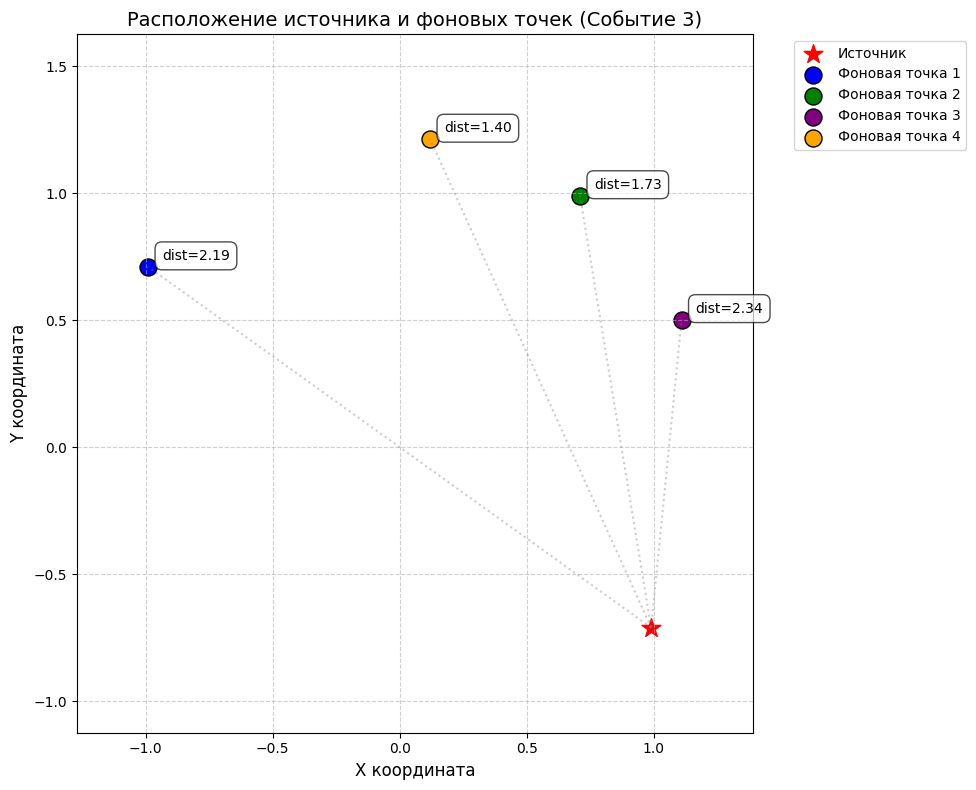

In [26]:
def plot_source_and_background_points(df, event_index=0):
    """
    Визуализирует координаты источника и 4 фоновых точек для конкретного события.
    
    Параметры:
    ----------
    df : DataFrame
        DataFrame с координатами точек
    event_index : int
        Индекс события для визуализации (по умолчанию первое событие)
    """
    # Получаем данные для выбранного события
    event = df.iloc[event_index]
    
    # Создаем фигуру
    plt.figure(figsize=(10, 8))
    
    # Рисуем источник
    plt.scatter(event['source_x'], event['source_y'], 
               color='red', s=200, label='Источник', marker='*')
    
    # Рисуем 4 фоновые точки
    background_colors = ['blue', 'green', 'purple', 'orange']
    for i in range(1, 5):
        bg_x = event[f'bg{i}_x']
        bg_y = event[f'bg{i}_y']
        plt.scatter(bg_x, bg_y, 
                   color=background_colors[i-1], 
                   s=150, 
                   label=f'Фоновая точка {i}',
                   edgecolors='black',
                   linewidth=1)
    
    # Настраиваем график
    plt.title(f'Расположение источника и фоновых точек (Событие {event_index})', fontsize=14)
    plt.xlabel('X координата', fontsize=12)
    plt.ylabel('Y координата', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Делаем масштаб равным по осям
    plt.axis('equal')
    
    # Добавляем соединительные линии от источника к фоновым точкам
    for i in range(1, 5):
        bg_x = event[f'bg{i}_x']
        bg_y = event[f'bg{i}_y']
        plt.plot([event['source_x'], bg_x], [event['source_y'], bg_y], 
                color='gray', linestyle=':', alpha=0.4)
    
    # Добавляем расстояния в аннотации
    for i in range(1, 5):
        bg_x = event[f'bg{i}_x']
        bg_y = event[f'bg{i}_y']
        dist = event[f'bg{i}_dist']
        plt.annotate(f'dist={dist:.2f}', 
                    xy=(bg_x, bg_y),
                    xytext=(10, 5), textcoords='offset points',
                    bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.7))
    
    plt.tight_layout()
    plt.show()

# Пример использования:
plot_source_and_background_points(df_with_points)  # для первого события

### Рисуем выбранные точки

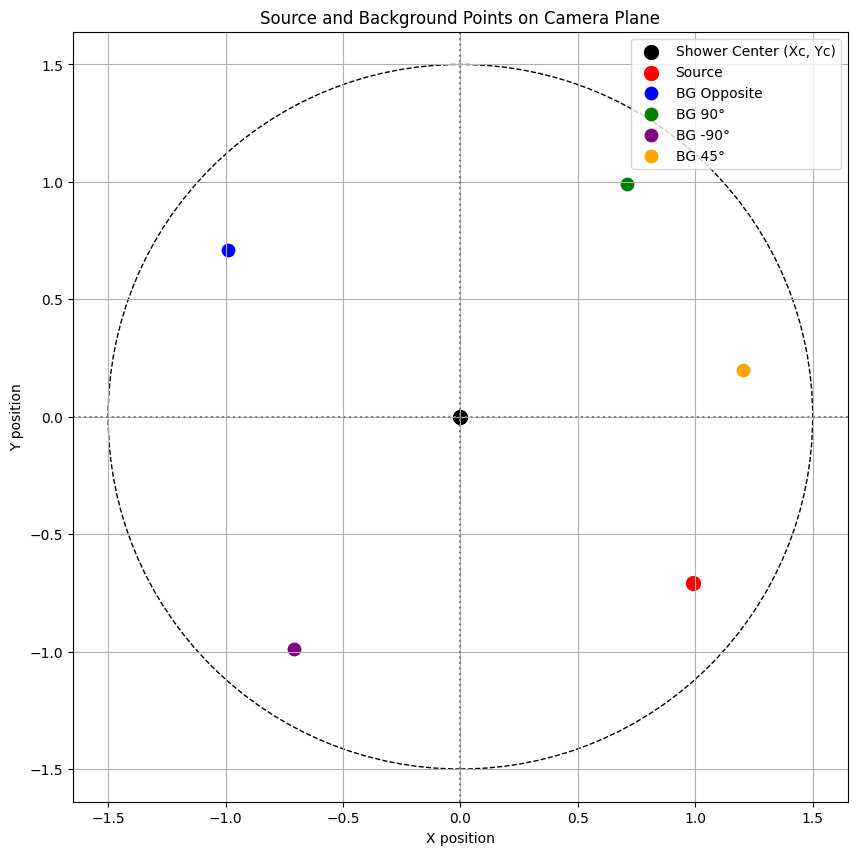

In [9]:
def plot_points_on_circle(df_sample):
    plt.figure(figsize=(10, 10))
    
    # Окружность камеры
    circle = plt.Circle((0, 0), 1.5, fill=False, color='black', linestyle='--')
    plt.gca().add_patch(circle)
    
    # Центр события (Xc, Yc)
    plt.scatter(0, 0, color='black', s=100, label='Shower Center (Xc, Yc)')
    
    # Точка источника
    plt.scatter(df_sample['source_x'], df_sample['source_y'], 
                color='red', s=100, label='Source')
    
    # Фоновые точки
    colors = ['blue', 'green', 'purple', 'orange']
    labels = ['Opposite', '90°', '-90°', '45°']
    
    for i in range(4):
        plt.scatter(df_sample[f'bg{i+1}_x'], df_sample[f'bg{i+1}_y'],
                    color=colors[i], s=80, label=f'BG {labels[i]}')
    
    # Настройки графика
    plt.axhline(0, color='gray', linestyle=':')
    plt.axvline(0, color='gray', linestyle=':')
    plt.xlabel('X position')
    plt.ylabel('Y position')
    plt.title('Source and Background Points on Camera Plane')
    plt.legend(loc='best')
    plt.grid(True)
    plt.axis('equal')
    plt.show()

# Выбираем одно событие для визуализации
sample_event = hillas_with_4point_background.iloc[0]  # Первое событие
plot_points_on_circle(sample_event)

### Накладываем каты

In [20]:
def filter_hillas_data_split_background(df):
    # Общие фильтры
    common_filters = (
        (df['CR_portion']/np.cos(np.pi/2-np.pi*df['tel_el']/180) > 5) &
        (df['size'] > 120) &
        (df['width'] > 0.024) &
        (df['width'] < 0.068 * np.log10(df['size']) - 0.047) &
        (df['length'] < 0.145 * np.log10(df['size']))
    )
    # Таблица с источником (dist1)
    source_df = df[
        common_filters &
        (df['dist1'].between(0.36, 1.44))
    ]
    # Отдельные таблицы для каждого фонового региона
    anti_source_df = df[
        common_filters &
        (df['dist2'].between(0.36, 1.44))
    ]
    bg1_df = df[
        common_filters &
        (df['bg1_dist'].between(0.36, 1.44))
    ]
    bg2_df = df[
        common_filters &
        (df['bg2_dist'].between(0.36, 1.44))
    ]
    bg3_df = df[
        common_filters &
        (df['bg3_dist'].between(0.36, 1.44))
    ]
    bg4_df = df[
        common_filters &
        (df['bg4_dist'].between(0.36, 1.44))
    ]
    return source_df, anti_source_df, bg1_df, bg2_df, bg3_df, bg4_df

source, anti_source, bg1, bg2, bg3, bg4 = filter_hillas_data_split_background(hillas_with_4point_background)
source

,por,event_numb,time,unix_time_ns,delta_time,error_deg,tel_az,tel_el,source_az,source_el,...,bg2_dist,bg2_alpha,bg3_x,bg3_y,bg3_dist,bg3_alpha,bg4_x,bg4_y,bg4_dist,bg4_alpha
709,1,13650,16:00:10:513:944:670,1574524810513944670,0.01,0.03,118.95592,47.336,120.40375,48.035,...,1.661361,67.125685,-0.71,-0.99,2.791171,127.290950,1.202082,0.197990,0.807742,85.764061
1574,2,26697,16:01:42:662:894:080,1574524902662894080,0.16,0.03,119.38536,47.540,120.84088,48.239,...,0.885293,107.459154,-0.71,-0.99,2.328885,166.304182,1.202082,0.197990,0.092302,134.367744
2351,2,32070,16:02:53:749:452:180,1574524973749452180,0.25,0.03,119.71657,47.702,121.18010,48.397,...,2.311046,45.562767,-0.71,-0.99,2.486793,106.472787,1.202082,0.197990,1.383196,42.604852
2360,2,32125,16:02:54:502:714:070,1574524974502714070,0.00,0.03,119.72204,47.703,121.18489,48.399,...,1.744907,72.073212,-0.71,-0.99,1.295838,177.630921,1.202082,0.197990,1.142128,42.885805
2668,3,34895,16:03:34:464:161:100,1574525014464161100,0.04,0.03,119.91109,47.795,121.37673,48.487,...,0.973727,57.015191,-0.70,-0.99,1.702544,175.153571,1.195010,0.205061,0.554908,11.550859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204384,137,1980882,21:00:02:206:774:700,1574542802206774700,0.21,0.03,239.02795,48.301,237.52513,48.984,...,0.868537,73.055314,-0.71,1.00,2.198732,23.373083,-0.205061,-1.209153,0.100054,154.759096
205056,137,1985258,21:01:12:396:970:200,1574542872396970200,0.40,0.03,239.36333,48.143,237.86575,48.831,...,1.134669,115.276651,-0.72,1.00,1.331169,60.890014,-0.197990,-1.216224,1.134473,164.393935
205490,138,1988450,21:02:09:852:156:110,1574542929852156110,0.15,0.03,239.63636,48.013,238.14674,48.704,...,2.344430,52.956636,-0.72,0.99,0.888163,33.033900,-0.190919,-1.209153,1.827072,74.711353
205740,138,1990099,21:02:35:978:715:980,1574542955978715980,0.02,0.03,239.75992,47.950,238.27234,48.647,...,2.364452,67.011731,-0.72,0.99,2.109626,0.945497,-0.190919,-1.209153,1.483180,76.754626


### Вычисляем тета

In [11]:
def calculate_theta2_for_all_separate(source_df, anti_source_df, bg1_df, bg2_df, bg3_df, bg4_df):
    def calculate_ksi(rc, size):
        """Функция для расчета коэффициента ksi"""
        if rc < 7.5:
            return 1.3
        elif rc <= 10:
            return 1.6
        else:
            if size < 700:
                return 2.0
            elif size < 1000:
                return 1.9
            elif size < 1250:
                return 1.75
            elif size < 1500:
                return 1.5
        return np.nan

    # 1. Обработка источника
    source_processed = source_df.copy()
    if 'dist1' in source_processed.columns:
        source_processed['source_rc'] = source_processed['dist1'] / 0.1206
        source_processed['source_ksi'] = source_processed.apply(
            lambda row: calculate_ksi(row['source_rc'], row['size']), axis=1)
        source_processed = source_processed[~source_processed['source_ksi'].isna()]  # Remove NaN values
        source_processed['source_disp'] = source_processed['source_ksi'] * (
            1.0 - source_processed['width'] / source_processed['length'])
        source_processed['source_theta2'] = (
            source_processed['source_disp']**2 + 
            source_processed['dist1']**2 - 
            2 * source_processed['source_disp'] * source_processed['dist1'] * 
            np.cos(np.radians(source_processed['alpha1'])))
        
        source_processed = source_processed.drop(
            columns=['source_rc', 'source_ksi', 'source_disp'], errors='ignore')

    # 2. Обработка антиисточника
    anti_source_processed = anti_source_df.copy()
    if 'dist2' in anti_source_processed.columns:
        anti_source_processed['dist2_rc'] = anti_source_processed['dist2'] / 0.1206
        anti_source_processed['dist2_ksi'] = anti_source_processed.apply(
            lambda row: calculate_ksi(row['dist2_rc'], row['size']), axis=1)
        anti_source_processed = anti_source_processed[~anti_source_processed['dist2_ksi'].isna()]  # Remove NaN value
        anti_source_processed['dist2_disp'] = anti_source_processed['dist2_ksi'] * (
            1.0 - anti_source_processed['width'] / anti_source_processed['length'])
        anti_source_processed['dist2_theta2'] = (
            anti_source_processed['dist2_disp']**2 + 
            anti_source_processed['dist2']**2 - 
            2 * anti_source_processed['dist2_disp'] * anti_source_processed['dist2'] * 
            np.cos(np.radians(anti_source_processed['alpha2'])))
        
        anti_source_processed = anti_source_processed.drop(
            columns=['dist2_rc', 'dist2_ksi', 'dist2_disp'], errors='ignore')

    # 3-6. Обработка 4 фоновых точек
    def process_bg(df, bg_num):
        """Обработка одной фоновой точки"""
        df = df.copy()
        prefix = f'bg{bg_num}_'
        
        df[f'{prefix}rc'] = df[f'{prefix}dist'] / 0.1206
        df[f'{prefix}ksi'] = df.apply(
            lambda row: calculate_ksi(row[f'{prefix}rc'], row['size']), axis=1)
        df = df[~df[f'{prefix}ksi'].isna()]  # Remove NaN values
        df[f'{prefix}disp'] = df[f'{prefix}ksi'] * (1.0 - df['width'] / df['length'])
        df[f'{prefix}theta2'] = (
            df[f'{prefix}disp']**2 + 
            df[f'{prefix}dist']**2 - 
            2 * df[f'{prefix}disp'] * df[f'{prefix}dist'] * 
            np.cos(np.radians(df[f'{prefix}alpha'])))
        
        return df.drop(columns=[f'{prefix}rc', f'{prefix}ksi', f'{prefix}disp'], errors='ignore')

    bg1_processed = process_bg(bg1_df, 1)
    bg2_processed = process_bg(bg2_df, 2)
    bg3_processed = process_bg(bg3_df, 3)
    bg4_processed = process_bg(bg4_df, 4)

    return (
        source_processed,
        anti_source_processed,
        bg1_processed,
        bg2_processed,
        bg3_processed,
        bg4_processed
    )

(source_processed, 
 anti_source_processed,
 bg1_processed,
 bg2_processed, 
 bg3_processed,
 bg4_processed) = calculate_theta2_for_all_separate(source, anti_source, bg1, bg2, bg3, bg4)

### Совмещенное распределение фона

In [43]:
print(anti_source_processed.source_x)
print(bg1_processed.bg1_x)

143       0.99
284       0.99
2416      0.99
3169      0.99
4658      1.00
          ... 
204464   -1.00
205056   -1.00
205821   -1.00
206528   -0.99
206592   -0.99
Name: source_x, Length: 216, dtype: float64
143      -0.99
284      -0.99
2416     -0.99
3169     -0.99
4658     -1.00
          ... 
204464    1.00
205056    1.00
205821    1.00
206528    0.99
206592    0.99
Name: bg1_x, Length: 217, dtype: float64


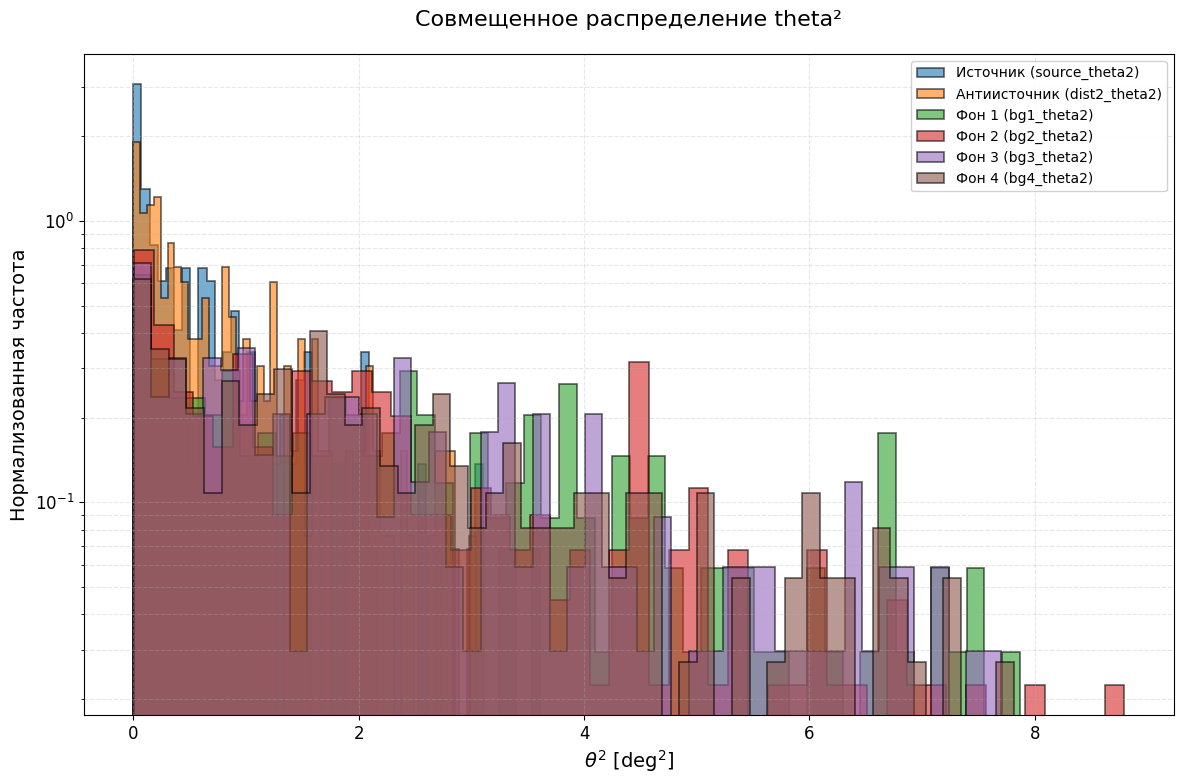

In [23]:
def plot_combined_theta2_histograms(source_df, anti_source_df, bg1_df, bg2_df, bg3_df, bg4_df, bins=40):
    plt.figure(figsize=(12, 8))
    
    # Настройки стиля
    plt.style.use('default')
    plt.rcParams['font.size'] = 12
    
    # Цвета и подписи для каждого распределения
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
    labels = [
        'Источник (source_theta2)',
        'Антиисточник (dist2_theta2)',
        'Фон 1 (bg1_theta2)',
        'Фон 2 (bg2_theta2)',
        'Фон 3 (bg3_theta2)',
        'Фон 4 (bg4_theta2)'
    ]
    
    # Собираем все данные
    datasets = [
        source_df['source_theta2'].dropna(),
        anti_source_df['dist2_theta2'].dropna(),
        bg1_df['bg1_theta2'].dropna(),
        bg2_df['bg2_theta2'].dropna(),
        bg3_df['bg3_theta2'].dropna(),
        bg4_df['bg4_theta2'].dropna()
    ]
    
    # Параметры гистограмм
    hist_kwargs = {
        'bins': bins,
        'density': True,
        'alpha': 0.6,
        'histtype': 'stepfilled',
        'linewidth': 1.2,
        'edgecolor': 'k'
    }
    
    # Строим все гистограммы
    for data, color, label in zip(datasets, colors, labels):
        plt.hist(data, color=color, label=label, **hist_kwargs)
    
    # Оптимизированные настройки графика
    plt.xlabel(r'$\theta^2$ [deg$^2$]', fontsize=14)
    plt.ylabel('Нормализованная частота', fontsize=14)
    plt.title('Совмещенное распределение theta²', fontsize=16, pad=20)
    
    plt.grid(True, which='both', linestyle='--', alpha=0.3)
    plt.legend(fontsize=10, framealpha=0.9)
    plt.yscale('log')
    
    # Добавляем общую статистику
    stats_text = "\n".join([
        f"{label.split(' (')[0]}: {len(data)} событий"
        for data, label in zip(datasets, labels)
    ])
    
    # plt.annotate(stats_text, xy=(0.65, 0.65), xycoords='axes fraction',
    #             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

# Вызов функции для построения графика
plot_combined_theta2_histograms(
    source_processed, 
 anti_source_processed,
 bg1_processed,
 bg2_processed, 
 bg3_processed,
 bg4_processed,
    bins=50
)

### 5 точек фона и источник

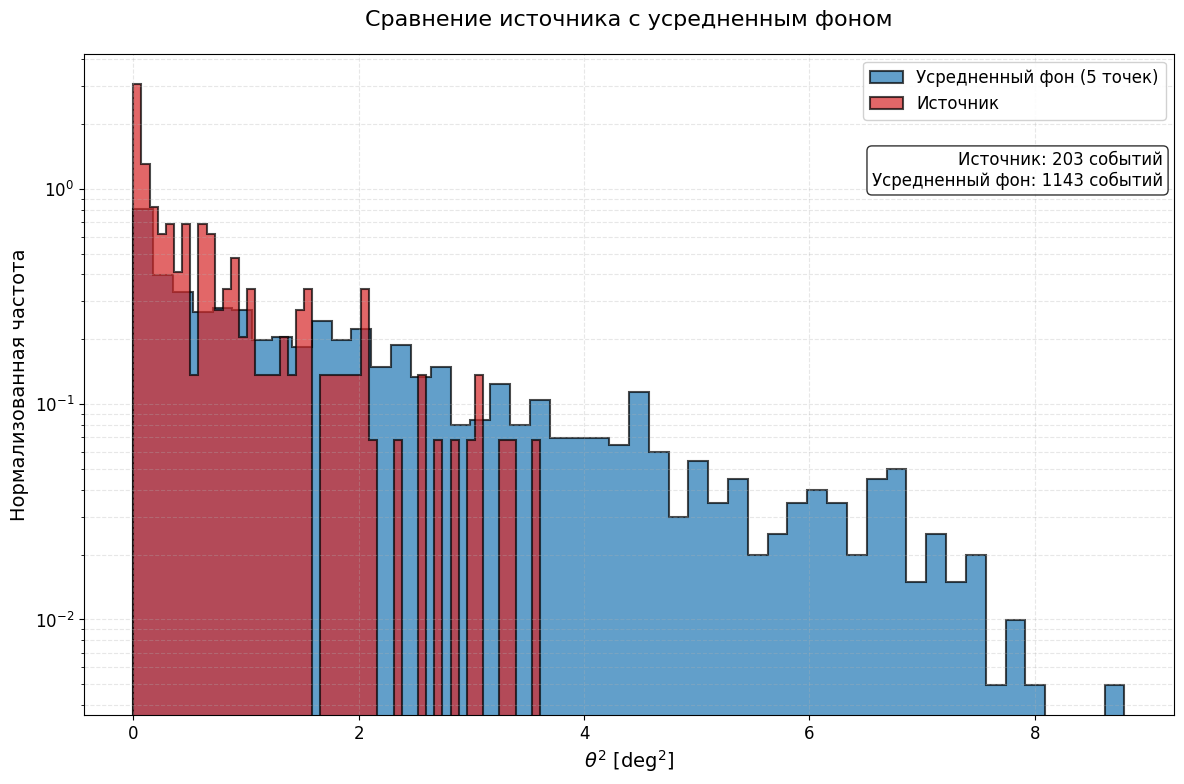

In [40]:
def plot_combined_with_averaged_background(source_df, anti_source_df, bg1_df, bg2_df, bg3_df, bg4_df, bins=40):
    plt.figure(figsize=(12, 8))
    
    # Настройки стиля
    plt.style.use('default')
    plt.rcParams['font.size'] = 12
    
    # Собираем все фоновые данные
    background_dfs = [
        anti_source_df['dist2_theta2'].dropna(),
        bg1_df['bg1_theta2'].dropna(),
        bg2_df['bg2_theta2'].dropna(),
        bg3_df['bg3_theta2'].dropna(),
        bg4_df['bg4_theta2'].dropna()
    ]
    
    # Объединяем все фоновые точки
    all_background = np.concatenate(background_dfs)
    
    # Данные источника
    source_data = source_df['source_theta2'].dropna()
    
    # Параметры гистограмм
    hist_kwargs = {
        'bins': bins,
        'density': True,
        'alpha': 0.7,
        'histtype': 'stepfilled',
        'linewidth': 1.5,
        'edgecolor': 'k'
    }
    
    # Строим гистограммы
    plt.hist(all_background, color='#1f77b4', label='Усредненный фон (5 точек)', **hist_kwargs)
    plt.hist(source_data, color='#d62728', label='Источник', **hist_kwargs)
    
    # Настройки графика
    plt.xlabel(r'$\theta^2$ [deg$^2$]', fontsize=14)
    plt.ylabel('Нормализованная частота', fontsize=14)
    plt.title('Сравнение источника с усредненным фоном', fontsize=16, pad=20)
    
    plt.grid(True, which='both', linestyle='--', alpha=0.3)
    plt.legend(fontsize=12, framealpha=0.9)
    plt.yscale('log')
    
    # Добавляем статистику
    stats_text = "\n".join([
        f"Источник: {len(source_data)} событий",
        f"Усредненный фон: {len(all_background)} событий"
    ])
    
    plt.annotate(stats_text, xy=(0.99, 0.8), xycoords='axes fraction',ha='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

# Вызов функции для построения графика
plot_combined_with_averaged_background(
    source_processed,
    anti_source_processed,
    bg1_processed,
    bg2_processed,
    bg3_processed,
    bg4_processed,
    bins=50
)

### Отдельные распределения для каждой точки

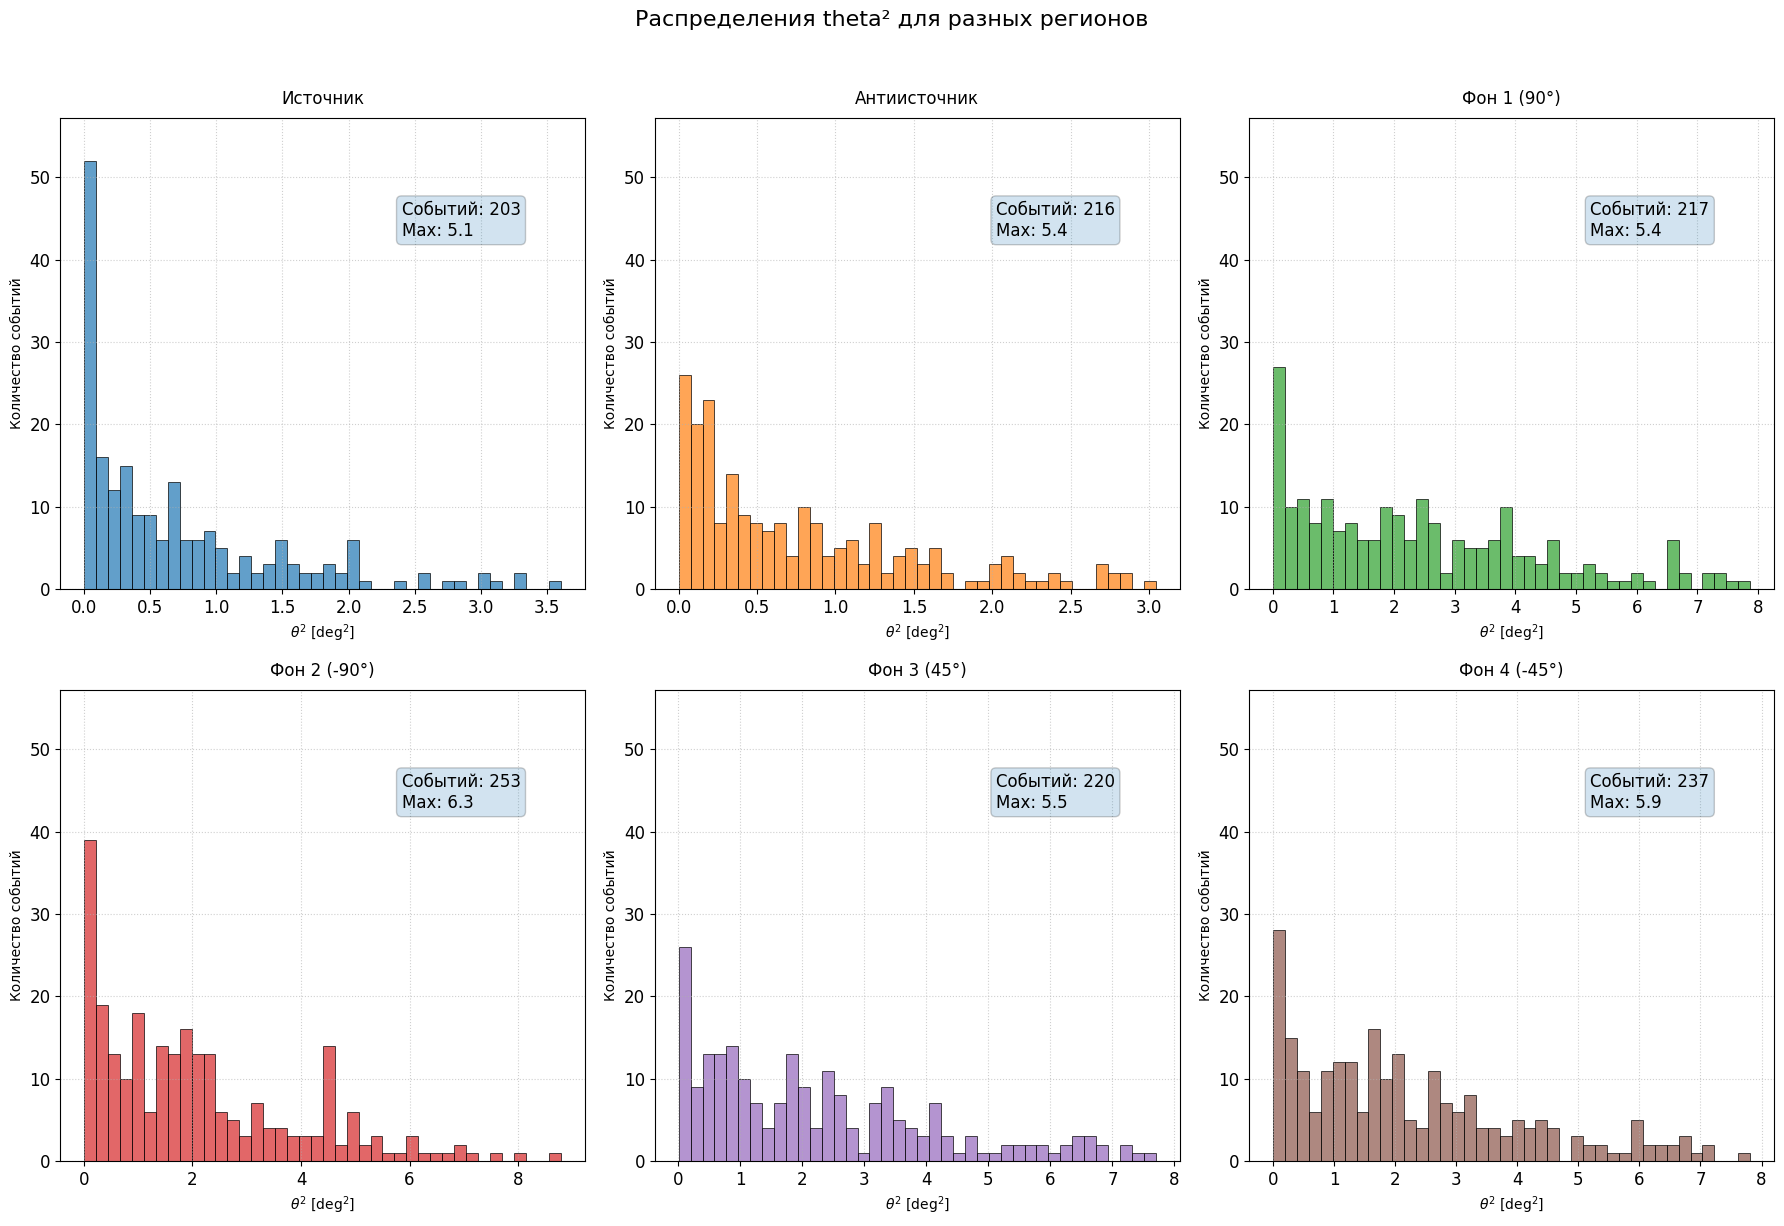

In [27]:
def plot_theta2_histograms_separate(source_df, anti_source_df, bg1_df, bg2_df, bg3_df, bg4_df, bins=30):
    # Создаем фигуру с 6 подграфиками (2 строки × 3 колонки)
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Распределения theta² для разных регионов', fontsize=16, y=1.02)
    
    # Цвета для каждого графика
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
    titles = ['Источник', 'Антиисточник', 'Фон 1 (90°)', 
              'Фон 2 (-90°)', 'Фон 3 (45°)', 'Фон 4 (-45°)']
    
    # Данные для каждого графика (в порядке расположения на рисунке)
    data_list = [
        (source_df['source_theta2'], 'source_theta2'),
        (anti_source_df['dist2_theta2'], 'dist2_theta2'),
        (bg1_df['bg1_theta2'], 'bg1_theta2'),
        (bg2_df['bg2_theta2'], 'bg2_theta2'),
        (bg3_df['bg3_theta2'], 'bg3_theta2'),
        (bg4_df['bg4_theta2'], 'bg4_theta2')
    ]
    
    # Сначала собираем все данные для определения общего масштаба
    all_clean_data = []
    for data, _ in data_list:
        clean_data = data[~np.isnan(data)]
        all_clean_data.append(clean_data)
    
    # Определяем общие пределы для оси Y (берем максимум из всех гистограмм)
    max_counts = []
    for clean_data in all_clean_data:
        counts, _ = np.histogram(clean_data, bins=bins)
        max_counts.append(counts.max())
    y_max = max(max_counts) * 1.1  # Добавляем 10% отступ
    
    # Строим гистограммы для каждого набора данных
    for ax, (data, col_name), color, title in zip(axes.flatten(), data_list, colors, titles):
        clean_data = data[~np.isnan(data)]
        
        # Основная гистограмма с фиксированными пределами Y
        ax.hist(clean_data, bins=bins, color=color, alpha=0.7, 
                edgecolor='black', linewidth=0.7)
        
        # Фиксируем одинаковые пределы для оси Y
        ax.set_ylim(0, y_max)
        
        # Настройки графика
        ax.set_title(title, fontsize=12, pad=10)
        ax.set_xlabel(r'$\theta^2$ [deg$^2$]', fontsize=10)
        ax.set_ylabel('Количество событий', fontsize=10)
        ax.grid(True, linestyle=':', alpha=0.6)
        
        # Добавляем статистику в аннотацию
        stats_text = (f'Событий: {len(clean_data)}\n'
                     f'Max: {len(clean_data)/bins:.1f}')
        ax.annotate(stats_text, xy=(0.65, 0.75), xycoords='axes fraction',
                    bbox=dict(boxstyle='round', alpha=0.2))
    
    # Регулировка отступов между подграфиками
    plt.tight_layout()
    plt.savefig('source_and_every_background_fixed_scale.png', dpi=300, bbox_inches='tight')
    plt.show()

# Вызов функции для построения графиков
plot_theta2_histograms_separate(
    source_processed, 
    anti_source_processed,
    bg1_processed,
    bg2_processed, 
    bg3_processed,
    bg4_processed,
    bins=40
)

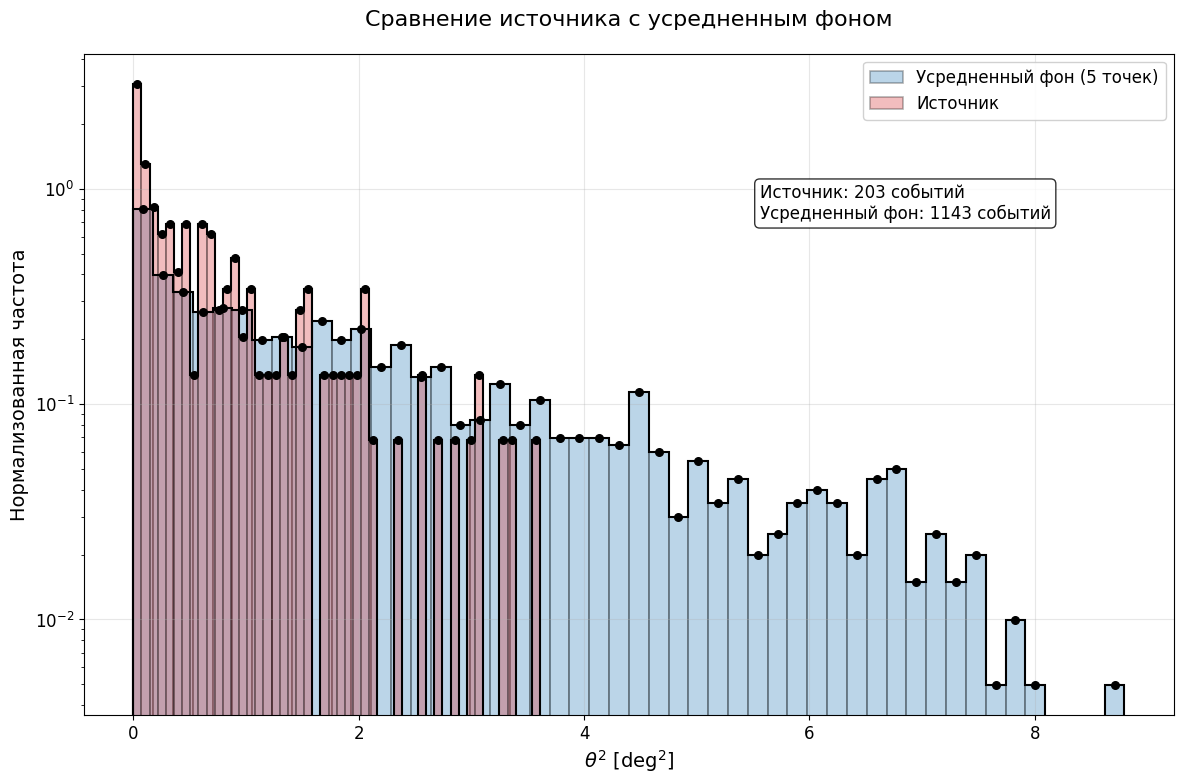

In [28]:
def plot_hist_with_points_and_outline(data, bins=30, color='blue', label=None, ax=None):
    """Вспомогательная функция для построения гистограммы с контуром и точками"""
    if ax is None:
        ax = plt.gca()
    
    # Строим гистограмму с прозрачной заливкой
    n, bins, patches = ax.hist(data, bins=bins, density=True, 
                              color=color, alpha=0.3, 
                              edgecolor='black', linewidth=1.2,
                              label=label)
    
    # Добавляем черный контур
    ax.hist(data, bins=bins, density=True, 
           histtype='step', color='black', linewidth=1.5,
           alpha=1.0)
    
    # Добавляем точки в центре каждого бина
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    ax.scatter(bin_centers, n, color='black', s=30, zorder=3)
    
    return n, bins, patches

def plot_combined_with_outlines(source_df, anti_source_df, bg1_df, bg2_df, bg3_df, bg4_df, bins=40):
    """
    Строит гистограмму с усредненным фоном и источником,
    используя стиль с черными контурами и точками
    """
    plt.figure(figsize=(12, 8))
    
    # Настройки стиля
    plt.style.use('default')
    plt.rcParams['font.size'] = 12
    plt.rcParams['axes.grid'] = True
    plt.rcParams['grid.alpha'] = 0.3
    
    # Собираем данные
    background_dfs = [
        anti_source_df['dist2_theta2'].dropna(),
        bg1_df['bg1_theta2'].dropna(),
        bg2_df['bg2_theta2'].dropna(),
        bg3_df['bg3_theta2'].dropna(),
        bg4_df['bg4_theta2'].dropna()
    ]
    all_background = np.concatenate(background_dfs)
    source_data = source_df['source_theta2'].dropna()
    
    # Строим гистограммы с новым стилем
    plot_hist_with_points_and_outline(all_background, bins=bins, 
                                    color='#1f77b4', 
                                    label='Усредненный фон (5 точек)')
    plot_hist_with_points_and_outline(source_data, bins=bins, 
                                    color='#d62728', 
                                    label='Источник')
    
    # Настройки графика
    plt.xlabel(r'$\theta^2$ [deg$^2$]', fontsize=14)
    plt.ylabel('Нормализованная частота', fontsize=14)
    plt.title('Сравнение источника с усредненным фоном', fontsize=16, pad=20)
    plt.yscale('log')
    plt.legend(fontsize=12, framealpha=0.9)
    
    # Статистика
    stats_text = "\n".join([
        f"Источник: {len(source_data)} событий",
        f"Усредненный фон: {len(all_background)} событий"
    ])
    plt.annotate(stats_text, xy=(0.62, 0.75), xycoords='axes fraction',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

# Вызов функции
plot_combined_with_outlines(
    source_processed,
    anti_source_processed,
    bg1_processed,
    bg2_processed,
    bg3_processed,
    bg4_processed,
    bins=50
)

In [ ]:
# суммарно 19 год добавить (после того, как Паша обработает)
# для тета: сгенерить 4 точки фона
# эффективную площадь построить